# Karnataka Paddy Seasonal Comparative Analysis

### Project Objective

The objective of this analysis is to examine district-level paddy cultivation data across Kharif, Rabi, and Summer seasons in Karnataka.

This study aims to:

- Compare seasonal yield variations across districts  
- Analyze production differences between seasons  
- Evaluate the impact of bund correction factors on cultivated area  
- Identify high-performing and low-performing districts across seasons  
- Validate whether “All Seasons” aggregates align with seasonal totals  

This analysis focuses purely on exploratory data analysis using Python.

In [ ]:
# 1. Import Required Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")

# Set basic plot style
sns.set_style("whitegrid")

In [ ]:
# 2. Load Dataset
df = pd.read_csv("Karnataka-Paddy-Analysis/NIC_Kar_Paddy.csv")

In [ ]:
# 3. Initial Data Inspection
df.shape

(31, 18)

In [ ]:
df.head()

,SlNo,District Name,Kharif_AreaBefore bund correction factor,Kharif_AreaAfter bund correction factor,Kharif_Yield,Kharif_Production,Rabi_AreaBefore bund correction factor,Rabi_AreaAfter bund correction factor,Rabi_Yield,Rabi_Production,Summer_AreaBefore bund correction factor,Summer_AreaAfter bund correction factor,Summer_Yield,Summer_Production,All Seasons_AreaBefore bund correction factor,All Seasons_Area After bund correction factor,All Seasons_Yield,All Seasons_Production
0,1.0,BAGALKOTE,35,34,4159,143,0,0,0,0,3,3,4616,14,38,37,4195,156
1,2.0,BENGALURU - URBAN,202,198,4242,840,0,0,0,0,74,73,4616,335,276,270,4342,1174
2,3.0,BENGALURU - RURAL,162,159,3372,535,0,0,0,0,31,30,4616,140,193,189,3572,676
3,4.0,BELAGAVI,57100,55958,4643,259813,0,0,0,0,173,170,4616,783,57273,56128,4643,260596
4,5.0,BALLARI,105169,103066,5853,603243,0,0,0,0,75422,73914,5327,393738,180591,176979,5633,996981


In [ ]:
# 4. Data Cleaning
#Drop unwanted Column 

df = df.drop('SlNo', axis=1)

#Drop unwanted Row
df = df[~(df['District Name'] == 'State Total')]

In [ ]:
# 5. Data Structure Validation
print(df.info())

#Lets see the Data Frame
df.head()

<class 'pandas.core.frame.DataFrame'>
Index: 30 entries, 0 to 29
Data columns (total 17 columns):
 #   Column                                         Non-Null Count  Dtype 
---  ------                                         --------------  ----- 
 0   District Name                                  30 non-null     object
 1   Kharif_AreaBefore bund correction factor       30 non-null     int64 
 2   Kharif_AreaAfter bund correction factor        30 non-null     int64 
 3   Kharif_Yield                                   30 non-null     int64 
 4   Kharif_Production                              30 non-null     int64 
 5   Rabi_AreaBefore bund correction factor         30 non-null     int64 
 6   Rabi_AreaAfter bund correction factor          30 non-null     int64 
 7   Rabi_Yield                                     30 non-null     int64 
 8   Rabi_Production                                30 non-null     int64 
 9   Summer_AreaBefore bund correction factor       30 non-null     int64 
 1

,District Name,Kharif_AreaBefore bund correction factor,Kharif_AreaAfter bund correction factor,Kharif_Yield,Kharif_Production,Rabi_AreaBefore bund correction factor,Rabi_AreaAfter bund correction factor,Rabi_Yield,Rabi_Production,Summer_AreaBefore bund correction factor,Summer_AreaAfter bund correction factor,Summer_Yield,Summer_Production,All Seasons_AreaBefore bund correction factor,All Seasons_Area After bund correction factor,All Seasons_Yield,All Seasons_Production
0,BAGALKOTE,35,34,4159,143,0,0,0,0,3,3,4616,14,38,37,4195,156
1,BENGALURU - URBAN,202,198,4242,840,0,0,0,0,74,73,4616,335,276,270,4342,1174
2,BENGALURU - RURAL,162,159,3372,535,0,0,0,0,31,30,4616,140,193,189,3572,676
3,BELAGAVI,57100,55958,4643,259813,0,0,0,0,173,170,4616,783,57273,56128,4643,260596
4,BALLARI,105169,103066,5853,603243,0,0,0,0,75422,73914,5327,393738,180591,176979,5633,996981


In [ ]:
# 6. Define Seasonal Column Groups

seasons = ["Kharif", "Rabi", "Summer"]

season_columns = {}

for season in seasons:
    season_columns[season] = [
        "District Name",
        f"{season}_AreaBefore bund correction factor",
        f"{season}_AreaAfter bund correction factor",
        f"{season}_Yield",
        f"{season}_Production"
    ]

season_columns

{'Kharif': ['District Name',
  'Kharif_AreaBefore bund correction factor',
  'Kharif_AreaAfter bund correction factor',
  'Kharif_Yield',
  'Kharif_Production'],
 'Rabi': ['District Name',
  'Rabi_AreaBefore bund correction factor',
  'Rabi_AreaAfter bund correction factor',
  'Rabi_Yield',
  'Rabi_Production'],
 'Summer': ['District Name',
  'Summer_AreaBefore bund correction factor',
  'Summer_AreaAfter bund correction factor',
  'Summer_Yield',
  'Summer_Production']}

In [ ]:
# 7. Standardize Column Names
df.columns = (
                df.columns
                .str.replace("bund correction factor", "", regex=False)
                .str.replace("AreaBefore", "AreaBefore", regex= False)
                .str.replace("AreaAfter ", "AreaAfter", regex= False)
                .str.strip()
                )

## Bund Correction Impact Analysis (All Seasons Aggregate)

In [ ]:
# Calculate total area before and after bund correction
total_area_before = df["All Seasons_AreaBefore"].sum()
total_area_after = df["All Seasons_Area After"].sum()

# Calculate absolute difference
area_difference = total_area_before - total_area_after

# Calculate percentage correction
area_correction_percent = round((area_difference / total_area_before) * 100, 2)

# Display results
print("Total Area Before Bund Correction :", total_area_before)
print("Total Area After Bund Correction  :", total_area_after)
print("Total Area Used for Bund Creation :", area_difference)
print("Percentage Area Used for Bund     :", area_correction_percent, "%")

Total Area Before Bund Correction : 1486588
Total Area After Bund Correction  : 1456856
Total Area Used for Bund Creation : 29732
Percentage Area Used for Bund     : 2.0 %


### Inference

- The total cultivated area reduced by **29,732 Hectares** after applying the bund correction factor.
- This corresponds to approximately **2%** of the total reported cultivated area.
- This indicates the extent of land adjustment made during bund correction across all districts.

Since this is an aggregate value, it does not show district-level variation.
Therefore, the next step is to evaluate bund correction impact season-wise and district-wise.

In [ ]:
# 8. Create Derived Metrics for Bund Correction (All Seasons)
df['All Seasons_AreaDiff'] = df['All Seasons_AreaBefore'] - df['All Seasons_Area After']

#Percentage Area Correction
df['AllSeasons_AreaCorrectionPercent'] = ((df['All Seasons_AreaDiff']/df['All Seasons_AreaBefore']*100).round(2))

#Check Preview
df[['District Name','All Seasons_AreaBefore','All Seasons_Area After' ,'All Seasons_AreaDiff','AllSeasons_AreaCorrectionPercent']]

,District Name,All Seasons_AreaBefore,All Seasons_Area After,All Seasons_AreaDiff,AllSeasons_AreaCorrectionPercent
0,BAGALKOTE,38,37,1,2.63
1,BENGALURU - URBAN,276,270,6,2.17
2,BENGALURU - RURAL,193,189,4,2.07
3,BELAGAVI,57273,56128,1145,2.00
4,BALLARI,180591,176979,3612,2.00
5,BIDAR,738,723,15,2.03
6,VIJAYAPURA,162,159,3,1.85
7,CHAMARAJANAGAR,10518,10308,210,2.00
8,CHICKBALLAPUR,6853,6716,137,2.00
9,CHIKMAGALUR,11070,10849,221,2.00


### Inference

- The bund correction factor reduces cultivated area by approximately 2% across nearly all districts.
- The consistency of correction percentage suggests a standardized administrative adjustment rather than district-specific land variation.
- Since the correction appears uniform at the aggregate level, further seasonal validation is required to confirm if this pattern holds for Kharif, Rabi, and Summer individually.

In [ ]:
# 9 Create Derived Metrics for All Individual Seasons
# Area Difference and Percentage Area Correction

seasons = ['Kharif', 'Rabi', 'Summer']


for item in seasons:
#Area Difference 
    df[f"{item}_AreaDiff"] = (
        df[f'{item}_AreaBefore'] - df[f"{item}_AreaAfter"]
    )
    

#Percentage Area Correction

for item in seasons:
    df[f"{item}_AreaCorrectionPercent"] = (
            ((df[f'{item}_AreaDiff']/df[f"{item}_AreaBefore"])*100).round(2)
    )

In [ ]:
#Lets Priview whats requried

df[["District Name",
    "Kharif_AreaBefore",
    "Kharif_AreaAfter",
    "Kharif_AreaDiff",
    "Kharif_AreaCorrectionPercent",
    "Rabi_AreaBefore",
    "Rabi_AreaAfter",
    "Rabi_AreaDiff",
    "Rabi_AreaCorrectionPercent",
    "Summer_AreaBefore",
    "Summer_AreaAfter",
    "Summer_AreaDiff",
    "Summer_AreaCorrectionPercent",
    'All Seasons_AreaBefore',
    'All Seasons_Area After',
    'All Seasons_AreaDiff',
    'AllSeasons_AreaCorrectionPercent']]




,District Name,Kharif_AreaBefore,Kharif_AreaAfter,Kharif_AreaDiff,Kharif_AreaCorrectionPercent,Rabi_AreaBefore,Rabi_AreaAfter,Rabi_AreaDiff,Rabi_AreaCorrectionPercent,Summer_AreaBefore,Summer_AreaAfter,Summer_AreaDiff,Summer_AreaCorrectionPercent,All Seasons_AreaBefore,All Seasons_Area After,All Seasons_AreaDiff,AllSeasons_AreaCorrectionPercent
0,BAGALKOTE,35,34,1,2.86,0,0,0,NaN,3,3,0,0.00,38,37,1,2.63
1,BENGALURU - URBAN,202,198,4,1.98,0,0,0,NaN,74,73,1,1.35,276,270,6,2.17
2,BENGALURU - RURAL,162,159,3,1.85,0,0,0,NaN,31,30,1,3.23,193,189,4,2.07
3,BELAGAVI,57100,55958,1142,2.00,0,0,0,NaN,173,170,3,1.73,57273,56128,1145,2.00
4,BALLARI,105169,103066,2103,2.00,0,0,0,NaN,75422,73914,1508,2.00,180591,176979,3612,2.00
5,BIDAR,614,602,12,1.95,0,0,0,NaN,124,122,2,1.61,738,723,15,2.03
6,VIJAYAPURA,128,125,3,2.34,0,0,0,NaN,34,33,1,2.94,162,159,3,1.85
7,CHAMARAJANAGAR,8330,8163,167,2.00,826,809,17,2.06,1362,1335,27,1.98,10518,10308,210,2.00
8,CHICKBALLAPUR,3630,3557,73,2.01,0,0,0,NaN,3223,3159,64,1.99,6853,6716,137,2.00
9,CHIKMAGALUR,10739,10524,215,2.00,0,0,0,NaN,331,324,7,2.11,11070,10849,221,2.00


In [ ]:
#Cleaning Columns 
df.columns =   (df.columns  
                .str.replace ('All Seasons_AreaBefore',"AllSeasons_AreaBefore", regex=False)
                .str.replace ('All Seasons_Area After', 'AllSeasons_AreaAfter', regex=False)  
                .str.replace ('All Seasons_Yield', 'AllSeasons_Yield', regex = False)
                .str.replace ('All Seasons_Production', 'AllSeasons_Production', regex = False)
                .str.replace ('All Seasons_AreaDiff', 'AllSeasons_AreaDiff', regex =False)
               )

In [ ]:
# Bund Correction Summary Table

seasons = ['Kharif', 'Rabi', 'Summer', 'AllSeasons']

summary_data = []

for item in seasons:
    before_col = f"{item}_AreaBefore"
    after_col  = f"{item}_AreaAfter"
    diff_col   = f"{item}_AreaDiff"
    pct_col    = f"{item}_AreaCorrectionPercent"
    
    total_before = df[before_col].sum()
    total_after  = df[after_col].sum()
    total_diff   = df[diff_col].sum()
    
    mean_pct  = df[pct_col].mean(skipna=True)
    min_pct   = df[pct_col].min(skipna=True)
    max_pct   = df[pct_col].max(skipna=True)
    std_pct   = df[pct_col].std(skipna=True)
    
    summary_data.append([
        item, total_before, total_after, total_diff, 
        round(mean_pct, 2), round(min_pct,2), round(max_pct,2), round(std_pct, 2)
        
    ])
    
bund_summary = pd.DataFrame(
            summary_data, columns=['Season',
                                  "Total_AreaBefore",
                                  "Total_AreaAfter",
                                  "Total_AreaDiff",
                                  "Avg_%Correction",
                                  "Min_%Correction",
                                  "Max_%Correction",
                                   "STD_Varation"
                             ]
)

bund_summary

,Season,Total_AreaBefore,Total_AreaAfter,Total_AreaDiff,Avg_%Correction,Min_%Correction,Max_%Correction,STD_Varation
0,Kharif,1028127,1007563,20564,2.03,1.85,2.86,0.17
1,Rabi,9365,9177,188,2.00,1.93,2.06,0.06
2,Summer,449096,440117,8979,1.89,0.00,3.23,0.75
3,AllSeasons,1486588,1456856,29732,2.03,1.85,2.63,0.12


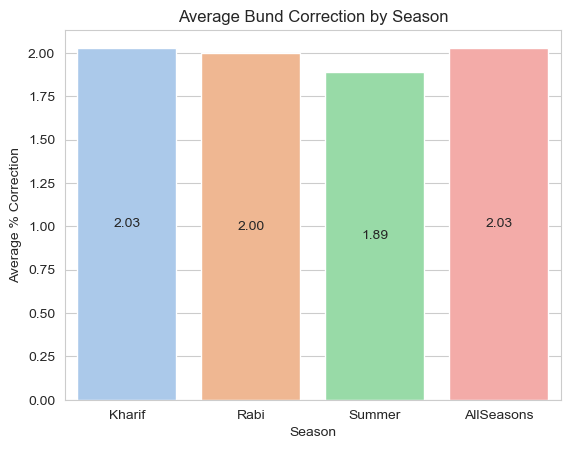

In [ ]:
#Bund Correction by Seasons Plot

import matplotlib.pyplot as plt

plt.figure()

ax = sns.barplot(
     x= bund_summary["Season"],
     y= bund_summary["Avg_%Correction"], 
     palette='pastel'
)


for container in ax.containers:
     ax.bar_label(container, label_type= 'center', fmt='%.2f')

plt.xlabel("Season")
plt.ylabel("Average % Correction")
plt.title("Average Bund Correction by Season")

plt.show()


### Bund Correction Inference

- Kharif season dominates paddy cultivation in Karnataka, accounting for the largest cultivated area (over 1.02 million hectares).
- Rabi season contributes negligibly to paddy cultivation, indicating that paddy is not a major Rabi crop across most districts.
- Summer cultivation is substantial (≈0.45 million hectares) and shows higher variability in correction percentage, likely due to differences in district-level participation and smaller base areas.
- The bund correction percentage remains close to 2% across seasons, supporting NIC documentation that a standardized 2% administrative correction factor is applied to gross cultivated area.
- The low standard deviation in Kharif and AllSeasons confirms consistency of implementation, while slightly higher variation in Summer suggests district-level proportional differences rather than policy deviation.

Since bund correction is administrative and uniformly applied, it does not materially explain agricultural intensity patterns. 

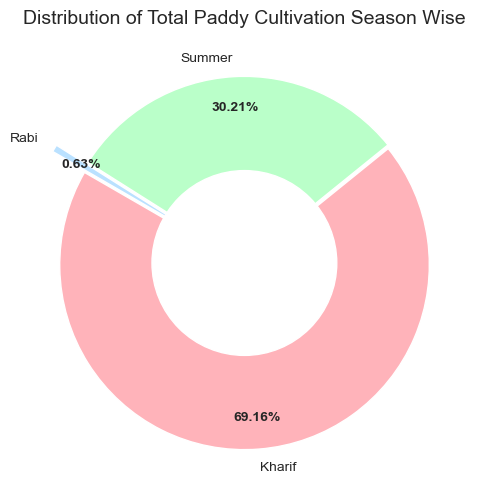

In [ ]:
#Distribution of Paddy Cultivation Season Wise 
labels = ['Kharif', 'Summer', 'Rabi']
sizes = [1028127, 449096, 9365] # Using Total_AreaBefore
colors = ['#ffb3ba', '#baffc9', '#bae1ff'] # Pastel colors

fig, ax = plt.subplots(figsize=(6, 6))

# Create the pie chart
wedges, texts, autotexts = ax.pie(
    sizes, 
    labels=labels, 
    autopct='%.2f%%', 
    startangle=150, 
    colors=colors,
    pctdistance=0.83, # Distance of percentage text from center
    explode=(0.01, 0.01, 0.2) # "Explode" Rabi slightly to make it visible
)

# Create the "Donut" hole
centre_circle = plt.Circle((0,0), 0.50, fc='white')
fig.gca().add_artist(centre_circle)

# Style the text
plt.setp(autotexts, size=10, weight="bold")
plt.title("Distribution of Total Paddy Cultivation Season Wise", fontsize=14)

plt.show()



- Kharif accounts for approximately 69% of total paddy cultivated area in Karnataka, indicating strong seasonal dependence.
- Summer contributes nearly 30%, suggesting supplementary seasonal support.
- Rabi contributes less than 1%, confirming that paddy is not structurally cultivated during Rabi in most districts.

In [ ]:
## Structural Tiering of Districts Based on Cultivated Area

# Creating Area Tier based on quantiles (All Seasons Area Before)

df['Area_Tier'] = pd.qcut(
    df['AllSeasons_AreaBefore'],
    q=3,                      # 3 tiers: Low, Medium, High
    labels=['Low Area', 'Medium Area', 'High Area']
)

# Summary table for each tier
tier_summary = df.groupby('Area_Tier').agg({
    'AllSeasons_AreaBefore': 'mean',
    'AllSeasons_AreaAfter': 'mean',
    'AllSeasons_AreaDiff': 'mean',
    'AllSeasons_AreaCorrectionPercent': 'mean',
    'AllSeasons_Yield': 'mean'
}).round(2)

tier_summary

,AllSeasons_AreaBefore,AllSeasons_AreaAfter,AllSeasons_AreaDiff,AllSeasons_AreaCorrectionPercent,AllSeasons_Yield
Area_Tier,,,,,
Low Area,2082.2,2040.4,41.8,2.08,3725.6
Medium Area,20481.7,20072.1,409.6,2.00,3909.8
High Area,126094.9,123573.1,2521.8,2.00,4629.2


In [ ]:
df.columns

Index(['District Name', 'Kharif_AreaBefore', 'Kharif_AreaAfter',
       'Kharif_Yield', 'Kharif_Production', 'Rabi_AreaBefore',
       'Rabi_AreaAfter', 'Rabi_Yield', 'Rabi_Production', 'Summer_AreaBefore',
       'Summer_AreaAfter', 'Summer_Yield', 'Summer_Production',
       'AllSeasons_AreaBefore', 'AllSeasons_AreaAfter', 'AllSeasons_Yield',
       'AllSeasons_Production', 'AllSeasons_AreaDiff',
       'AllSeasons_AreaCorrectionPercent', 'Kharif_AreaDiff', 'Rabi_AreaDiff',
       'Summer_AreaDiff', 'Kharif_AreaCorrectionPercent',
       'Rabi_AreaCorrectionPercent', 'Summer_AreaCorrectionPercent',
       'Area_Tier'],
      dtype='object')

In [ ]:
#Correlation Reality Check
correlation = df[['AllSeasons_AreaAfter', 'AllSeasons_Production', 'AllSeasons_Yield']].corr().round(2)
correlation

,AllSeasons_AreaAfter,AllSeasons_Production,AllSeasons_Yield
AllSeasons_AreaAfter,1.00,0.99,0.45
AllSeasons_Production,0.99,1.00,0.50
AllSeasons_Yield,0.45,0.50,1.00


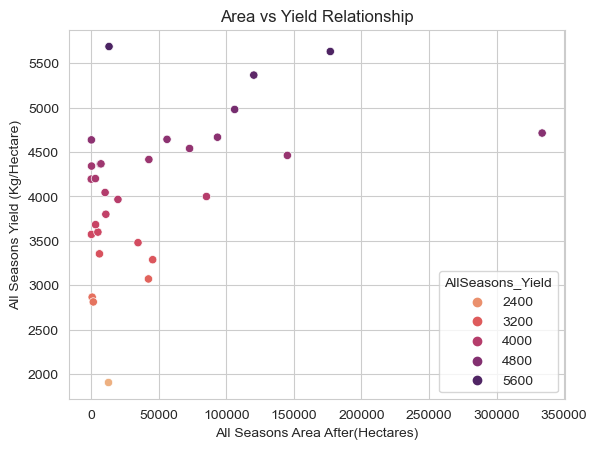

In [ ]:
## Lets visualize Area vs Yeld 
plt.figure()
sns.scatterplot(x='AllSeasons_AreaAfter', y='AllSeasons_Yield', hue='AllSeasons_Yield',data=df,palette="flare", )
plt.xlabel('All Seasons Area After(Hectares)')
plt.ylabel('All Seasons Yield (Kg/Hectare)')
plt.title('Area vs Yield Relationship')
plt.show()

In [ ]:
#Lets Check Yield district wise 

# Top 5 High Yield Districts
top_yield = df.sort_values('AllSeasons_Yield', ascending=False)[
    ['District Name', 'AllSeasons_AreaAfter', 'AllSeasons_Yield']
]
top_yield

,District Name,AllSeasons_AreaAfter,AllSeasons_Yield
15,KALBURGI,13210,5689
4,BALLARI,176979,5633
12,DAVANAGERE,120345,5367
20,KOPPAL,106191,4980
23,RAICHUR,333751,4714
22,MYSURU,93471,4667
3,BELAGAVI,56128,4643
6,VIJAYAPURA,159,4637
21,MANDYA,72822,4540
29,YADGIR,145204,4462


#### Paddy production in Karnataka is strongly scale-driven.
The near-perfect correlation (0.99) between cultivated area and production confirms that output volume primarily depends on how much land is cultivated.

#### Yield efficiency moderately influences performance.
The 0.45 correlation between Area and Yield indicates that larger districts tend to perform better, but size alone does not guarantee higher efficiency.

#### Efficiency differentiates districts within similar scale bands.
Districts with comparable cultivated area show meaningful yield variation, suggesting structural performance differences beyond land size.

#### Overall Model Identified is:
Karnataka’s paddy system operates as a scale-dominant structure with efficiency-based differentiation.

## District Contribution to Total Production

In [ ]:
## Lets find Total Production
total_production = df['AllSeasons_Production'].sum()

## Contribution Percentage
df['Production_Contribution_%'] = (df['AllSeasons_Production']/total_production *100).round(3)

## Rank districts by contribution
production_rank = df.sort_values('Production_Contribution_%', ascending=False)[['District Name','Area_Tier','AllSeasons_Production','Production_Contribution_%']]

production_rank

,District Name,Area_Tier,AllSeasons_Production,Production_Contribution_%
23,RAICHUR,High Area,1573334,23.325
4,BALLARI,High Area,996981,14.781
29,YADGIR,High Area,647931,9.606
12,DAVANAGERE,High Area,645874,9.575
20,KOPPAL,High Area,528804,7.840
22,MYSURU,High Area,436211,6.467
25,SHIVAMOGGA,High Area,341202,5.058
21,MANDYA,High Area,330620,4.902
3,BELAGAVI,High Area,260596,3.863
27,UDUPI,Medium Area,188579,2.796


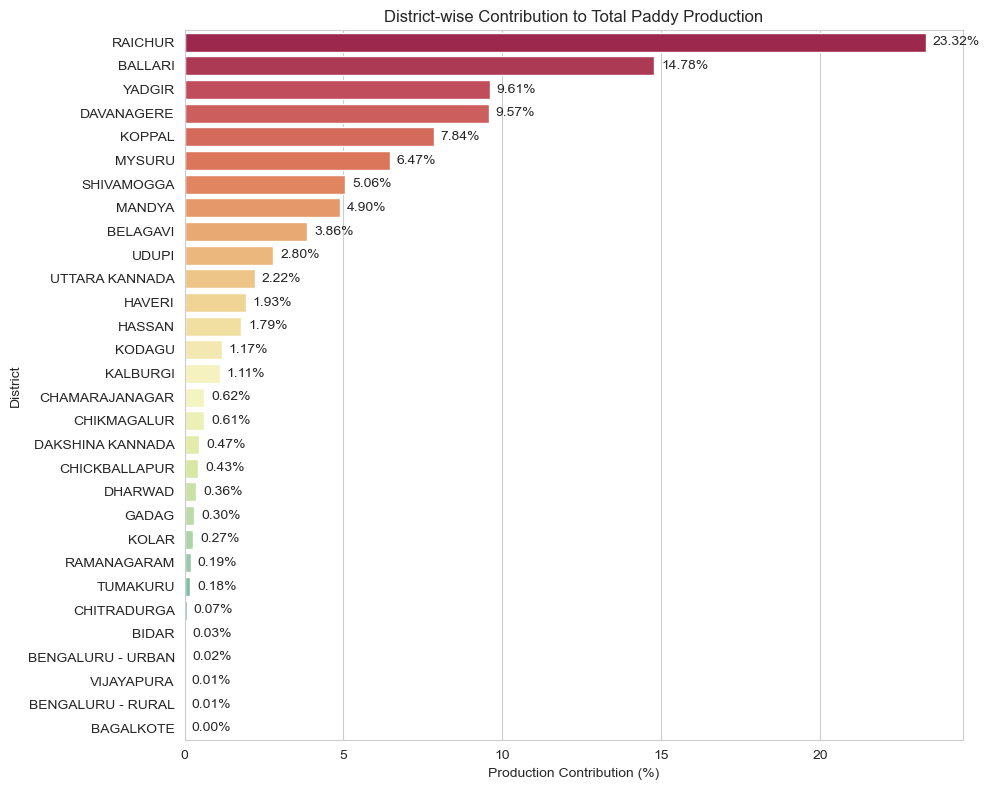

In [ ]:
# Sort data for plotting
plot_df = production_rank.sort_values(
    'Production_Contribution_%', ascending=False
)

plt.figure(figsize=(10,8))



ax = sns.barplot(
    x='Production_Contribution_%', 
    y='District Name', 
    data=plot_df, 
    palette='Spectral'
)
# Add the data labels to the bars

ax.bar_label(ax.containers[0], padding=5, fmt='%.2f%%')

plt.xlabel('Production Contribution (%)')
plt.ylabel('District')
plt.title('District-wise Contribution to Total Paddy Production')
plt.tight_layout()
plt.show()

- Paddy production in Karnataka is heavily concentrated in a small number of districts.

- Raichur alone contributes over 23% of total production.

- The top 5 districts together account for approximately 65–68% of total output.

- A large number of districts individually contribute less than 2%, indicating significant production asymmetry.

## Quantifying Agricultural Inequality Formally

In [ ]:
# Cumulative Contribution (Pareto Curve)

# Sort by contribution descending
pareto_df = production_rank.sort_values(
    'Production_Contribution_%', ascending=False
).reset_index(drop=True)

# Cumulative contribution
pareto_df['Cumulative_%'] = pareto_df['Production_Contribution_%'].cumsum()

pareto_df[['District Name',
           'Production_Contribution_%',
           'Cumulative_%']]

,District Name,Production_Contribution_%,Cumulative_%
0,RAICHUR,23.325,23.325
1,BALLARI,14.781,38.106
2,YADGIR,9.606,47.712
3,DAVANAGERE,9.575,57.287
4,KOPPAL,7.840,65.127
5,MYSURU,6.467,71.594
6,SHIVAMOGGA,5.058,76.652
7,MANDYA,4.902,81.554
8,BELAGAVI,3.863,85.417
9,UDUPI,2.796,88.213


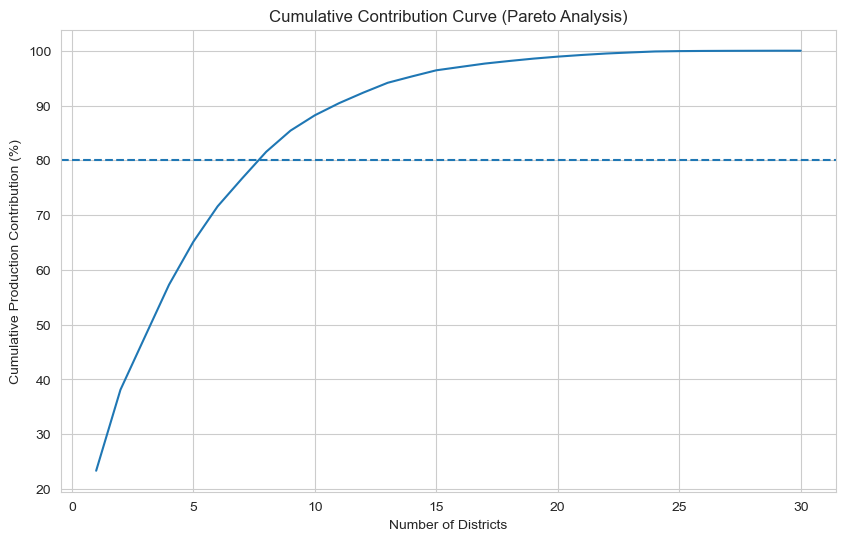

In [ ]:
#Plot for Pareto Curve
plt.figure(figsize=(10,6))

sns.lineplot(
    x=range(1, len(pareto_df)+1),
    y=pareto_df['Cumulative_%']
)

plt.axhline(80, linestyle='--')
plt.xlabel('Number of Districts')
plt.ylabel('Cumulative Production Contribution (%)')
plt.title('Cumulative Contribution Curve (Pareto Analysis)')
plt.show()

- The cumulative contribution curve shows that the top 8 districts account for over 80% of total paddy production.

- This confirms a Pareto-like structure where a minority of districts drive the majority of output.

- Beyond the top production belts, marginal increases in cumulative contribution flatten significantly, indicating diminishing structural weight from remaining districts.

In [ ]:
#Gini Coefficient

# Production values
production_values = np.sort(df['AllSeasons_Production'].values)

n = len(production_values)
cumulative = np.cumsum(production_values)

gini = (n + 1 - 2 * np.sum(cumulative) / cumulative[-1]) / n

print("Gini Coefficient:", round(gini, 3))

Gini Coefficient: 0.695


- The Gini coefficient of  **0.695 indicates very high production inequality across districts.**

- This level of concentration suggests that Karnataka’s paddy ecosystem is structurally dependent on a limited number of high-performing districts.

- Such concentration implies systemic vulnerability, as climatic or irrigation disruptions in key districts could significantly impact statewide production.

### Efficiency vs Contribution Quadrant

In [ ]:
# Median thresholds
median_yield = df['AllSeasons_Yield'].median()
median_contribution = df['Production_Contribution_%'].median()

# Create structural quadrant classification
def classify(row):
    if row['AllSeasons_Yield'] >= median_yield and row['Production_Contribution_%'] >= median_contribution:
        return "Core Belt (High Efficiency + High Contribution)"
    elif row['AllSeasons_Yield'] < median_yield and row['Production_Contribution_%'] >= median_contribution:
        return "Scale Belt (Low Efficiency + High Contribution)"
    elif row['AllSeasons_Yield'] >= median_yield and row['Production_Contribution_%'] < median_contribution:
        return "Efficiency Outlier (High Efficiency + Low Contribution)"
    else:
        return "Marginal Belt (Low Efficiency + Low Contribution)"

df['Structural_Type'] = df.apply(classify, axis=1)

df[['District Name',
    'AllSeasons_Yield',
    'Production_Contribution_%',
    'Area_Tier',
    'Structural_Type']].sort_values('Production_Contribution_%', ascending=False)

,District Name,AllSeasons_Yield,Production_Contribution_%,Area_Tier,Structural_Type
23,RAICHUR,4714,23.325,High Area,Core Belt (High Efficiency + High Contribution)
4,BALLARI,5633,14.781,High Area,Core Belt (High Efficiency + High Contribution)
29,YADGIR,4462,9.606,High Area,Core Belt (High Efficiency + High Contribution)
12,DAVANAGERE,5367,9.575,High Area,Core Belt (High Efficiency + High Contribution)
20,KOPPAL,4980,7.840,High Area,Core Belt (High Efficiency + High Contribution)
22,MYSURU,4667,6.467,High Area,Core Belt (High Efficiency + High Contribution)
25,SHIVAMOGGA,3999,5.058,High Area,Scale Belt (Low Efficiency + High Contribution)
21,MANDYA,4540,4.902,High Area,Core Belt (High Efficiency + High Contribution)
3,BELAGAVI,4643,3.863,High Area,Core Belt (High Efficiency + High Contribution)
27,UDUPI,4416,2.796,Medium Area,Core Belt (High Efficiency + High Contribution)


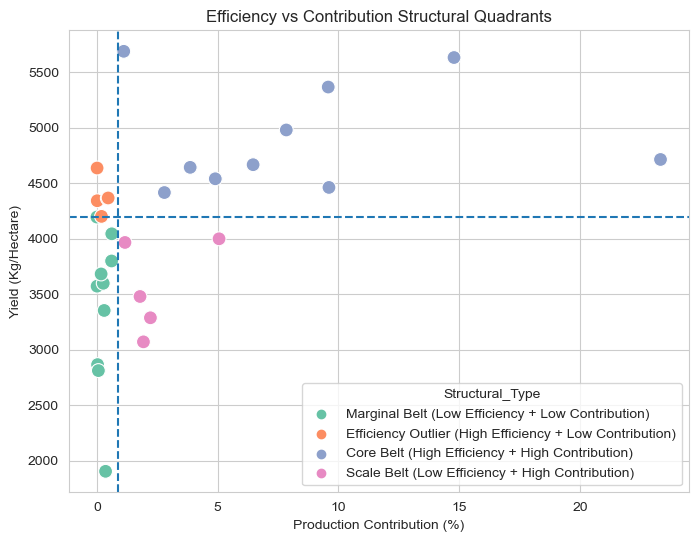

In [ ]:
#Visualize Quadrants

plt.figure(figsize=(8,6))

sns.scatterplot(
    x='Production_Contribution_%',
    y='AllSeasons_Yield',
    hue='Structural_Type',
    data=df,
    palette='Set2',
    s=100
)

plt.axvline(median_contribution, linestyle='--')
plt.axhline(median_yield, linestyle='--')

plt.xlabel('Production Contribution (%)')
plt.ylabel('Yield (Kg/Hectare)')
plt.title('Efficiency vs Contribution Structural Quadrants')
plt.show()

#### Core Belt

- High efficiency + high contribution

- These districts form the structural backbone of Karnataka’s paddy system.

- They combine scale and productivity.

#### Scale Belt

- High contribution but below-median efficiency

- Large producers driven more by land scale than productivity.

- Potential efficiency improvement zone.

#### Efficiency Outliers

- High yield but low contribution

- Technically strong districts with limited land scale.

- Represent productivity potential if scaled.

#### Marginal Belt

- Low yield + low contribution

- Structurally peripheral in paddy production.

In [ ]:
# Total state production
total_production = df['AllSeasons_Production'].sum()

# Core Belt subset
core_df = df[df['Structural_Type'] == 
             "Core Belt (High Efficiency + High Contribution)"]

# Core Belt production share
core_production = core_df['AllSeasons_Production'].sum()
core_share = (core_production / total_production) * 100

print("Core Belt Production Share (%):", round(core_share, 2))


# Average yield comparison
core_avg_yield = core_df['AllSeasons_Yield'].mean()
non_core_avg_yield = df[df['Structural_Type'] != 
                         "Core Belt (High Efficiency + High Contribution)"]['AllSeasons_Yield'].mean()

print("Core Belt Avg Yield:", round(core_avg_yield, 2))
print("Non-Core Avg Yield:", round(non_core_avg_yield, 2))

Core Belt Production Share (%): 84.27
Core Belt Avg Yield: 4911.1
Non-Core Avg Yield: 3676.75


In [ ]:
# 1. Group by all belts using median for Yield
belt_summary = df.groupby('Structural_Type').agg(
    Total_Production=('AllSeasons_Production', 'sum'),
    Median_Yield=('AllSeasons_Yield', 'median')
).reset_index()

# 2. Calculate Production Share (%)
total_state_prod = belt_summary['Total_Production'].sum()
belt_summary['Prod_Share_%'] = (belt_summary['Total_Production'] / total_state_prod * 100).round(2)

# 3. Add Efficiency Index (Belt Median / Overall Median)
overall_median_yield = df['AllSeasons_Yield'].median()
belt_summary['Efficiency_Index'] = (belt_summary['Median_Yield'] / overall_median_yield).round(2)

# 4. Rank them by Efficiency
belt_summary = belt_summary.sort_values(by='Efficiency_Index', ascending=False)
belt_summary

,Structural_Type,Total_Production,Median_Yield,Prod_Share_%,Efficiency_Index
0,Core Belt (High Efficiency + High Contribution),5684084,4690.5,84.27,1.12
1,Efficiency Outlier (High Efficiency + Low Cont...,75961,4365.0,1.13,1.04
2,Marginal Belt (Low Efficiency + Low Contribution),165019,3585.0,2.45,0.85
3,Scale Belt (Low Efficiency + High Contribution),820102,3479.0,12.16,0.83


- The Core Belt accounts for 84.27% of total paddy production.

- The Core Belt operates at a 12% higher median yield than the state median.

- The Gini coefficient of 0.695 confirms extreme production inequality.

- Production is both scale-driven and efficiency-reinforced within dominant districts.

### Implications for Karnataka’s Paddy Structure

- Karnataka’s paddy production is structurally centralized in a limited number of high-performing districts.

- Efficiency advantages within the Core Belt amplify production concentration.

- Peripheral districts play a marginal role in statewide output despite participating in cultivation.

- Agricultural planning and resource allocation may inherently revolve around these dominant production corridors.